# Histogramas Globales por Variable
Visualización de histogramas y estadísticas desde un JSON pre-computado.
No requiere cargar cubos ni tensores.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Config ───────────────────────────────────────────────────────────────────
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'data').exists() and (REPO_ROOT.parent / 'data').exists():
    REPO_ROOT = REPO_ROOT.parent

JSON_PATH = REPO_ROOT / 'data' / 'processed' / 'histogramas' / 'x.json'

print('JSON:', JSON_PATH)
print('Existe:', JSON_PATH.exists())

JSON: L:\cmg22tensor\data\processed\histogramas\x.json
Existe: True


In [2]:
payload = json.loads(JSON_PATH.read_text(encoding='utf-8'))
variables = [k for k in payload if k != '_meta']
meta = payload.get('_meta', {})

print(f'Variables encontradas : {variables}')
print(f'Simulaciones procesadas: {meta.get("total_simulations", "N/A")}')
print(f'Construido el         : {meta.get("built_at", "N/A")}')
print(f'Última actualización  : {meta.get("last_updated", "N/A")}')

Variables encontradas : ['AFI', 'COHESION', 'SF', 'VD']
Simulaciones procesadas: 309
Construido el         : 2026-04-28T19:40:09
Última actualización  : 2026-04-28T19:40:09


In [3]:
# ── Tabla de estadísticas ────────────────────────────────────────────────────
rows = []
for var in variables:
    s = payload[var]
    rows.append({
        'Variable': var,
        'n':        f"{s['n']:,}",
        'min':      f"{s['min']:.6g}",
        'max':      f"{s['max']:.6g}",
        'mean':     f"{s['mean']:.6g}",
        'std':      f"{s['std']:.6g}",
        'p5':       f"{s['p5']:.6g}" if s.get('p5') is not None else 'N/A',
        'p50':      f"{s['p50']:.6g}" if s.get('p50') is not None else 'N/A',
        'p95':      f"{s['p95']:.6g}" if s.get('p95') is not None else 'N/A',
    })

try:
    import pandas as pd
    df = pd.DataFrame(rows).set_index('Variable')
    display(df)
except ImportError:
    col_w = {'Variable': 12, 'n': 14, 'min': 12, 'max': 12,
             'mean': 12, 'std': 12, 'p5': 12, 'p50': 12, 'p95': 12}
    header = ''.join(c.ljust(col_w[c]) for c in col_w)
    print(header)
    print('-' * len(header))
    for r in rows:
        print(''.join(str(r[c]).ljust(col_w[c]) for c in col_w))

,n,min,max,mean,std,p5,p50,p95
Variable,,,,,,,,
AFI,"24,977,500",23.34,43.4439,35.6449,5.56273,24.236,35.3268,43.2209
COHESION,"24,977,500",687.85,1305.8,929.944,134.625,836.661,872.675,1171.73
SF,"9,041,855,000",0.740744,0.977709,0.875026,0.0303529,0.817365,0.878975,0.922233
VD,"9,041,855,000",-0.0532307,0.276087,0.0488005,0.0526394,-0.0124755,0.0322674,0.158193


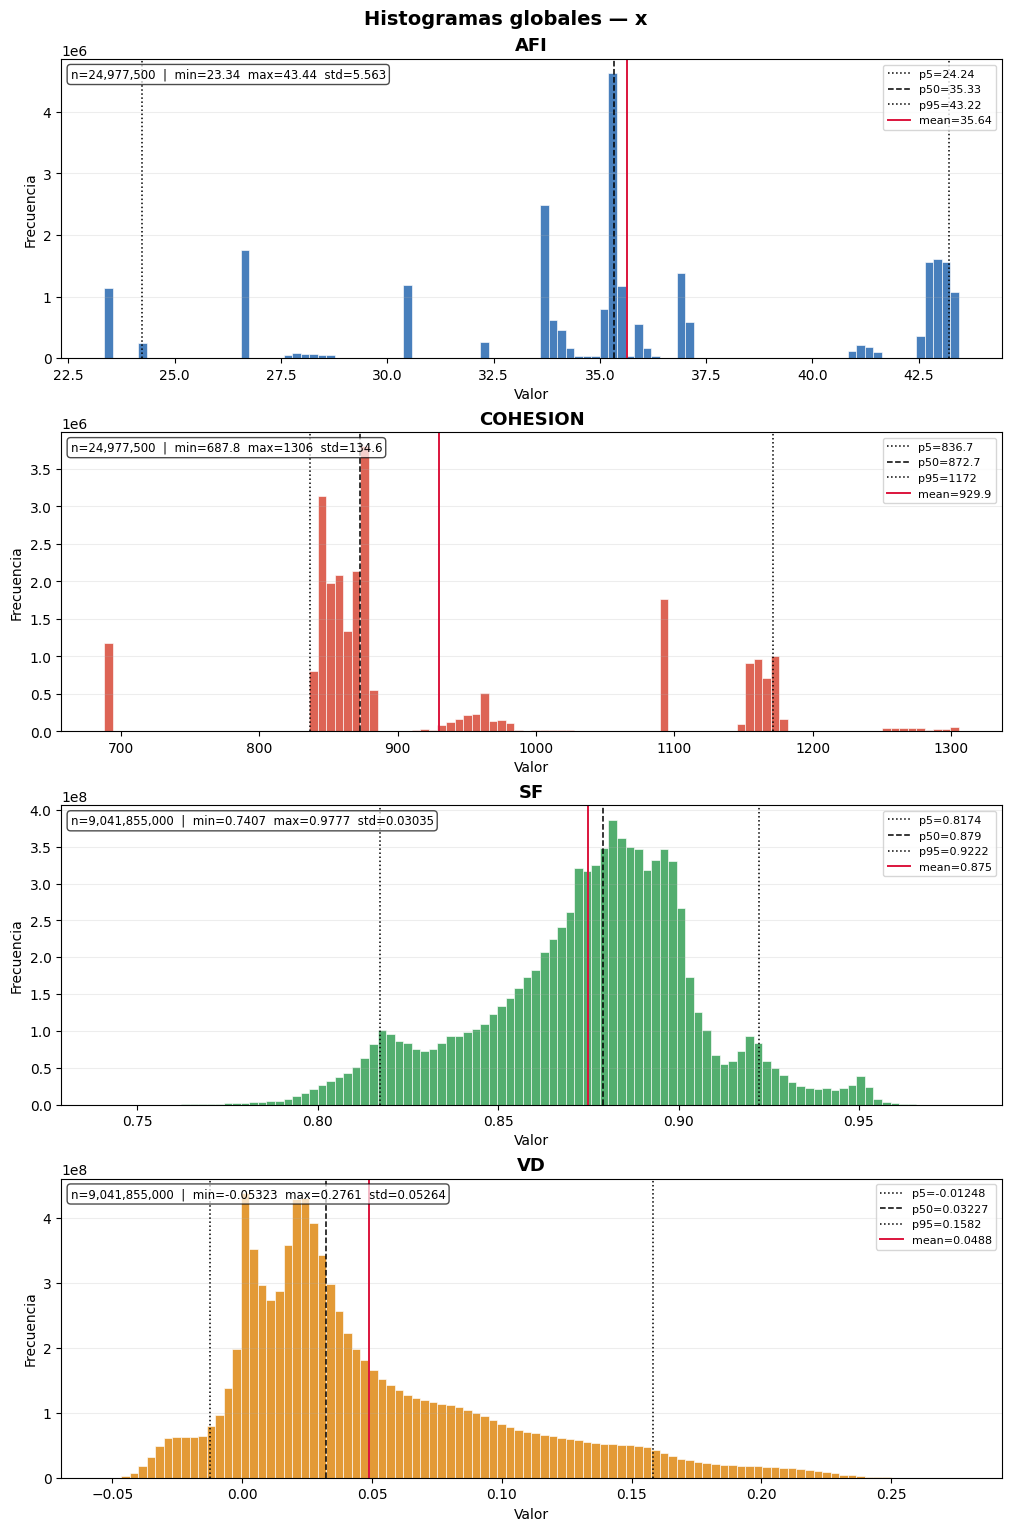

In [4]:
# ── Histogramas ──────────────────────────────────────────────────────────────
PALETTE = ['#2f6db3', '#d94f3d', '#3ba35b', '#e08c1a', '#7b4fa6']
LOG_Y   = False   # True para escala logarítmica en Y

n_vars = len(variables)
fig, axes = plt.subplots(n_vars, 1, figsize=(10, 3.8 * n_vars), constrained_layout=True)
if n_vars == 1:
    axes = [axes]

for ax, var, color in zip(axes, variables, PALETTE):
    s      = payload[var]
    edges  = np.asarray(s['bins'],   dtype=np.float64)
    counts = np.asarray(s['counts'], dtype=np.int64)
    widths = np.diff(edges)

    ax.bar(edges[:-1], counts, width=widths, align='edge',
           color=color, edgecolor='white', linewidth=0.5, alpha=0.88)

    if LOG_Y:
        ax.set_yscale('log')

    # Líneas de percentiles
    for pval, plabel, ls in [
        (s.get('p5'),  'p5',  ':'),
        (s.get('p50'), 'p50', '--'),
        (s.get('p95'), 'p95', ':'),
    ]:
        if pval is not None:
            ax.axvline(pval, color='black', linewidth=1.1, linestyle=ls,
                       label=f'{plabel}={pval:.4g}')

    ax.axvline(s['mean'], color='crimson', linewidth=1.4, linestyle='-',
               label=f"mean={s['mean']:.4g}")

    ax.set_title(f'{var}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, axis='y', alpha=0.22)

    info = (f"n={s['n']:,}  |  min={s['min']:.4g}  max={s['max']:.4g}  "
            f"std={s['std']:.4g}")
    ax.text(0.01, 0.97, info, transform=ax.transAxes,
            va='top', ha='left', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

fig.suptitle(f'Histogramas globales — {JSON_PATH.stem}',
             fontsize=14, fontweight='bold')
plt.show()

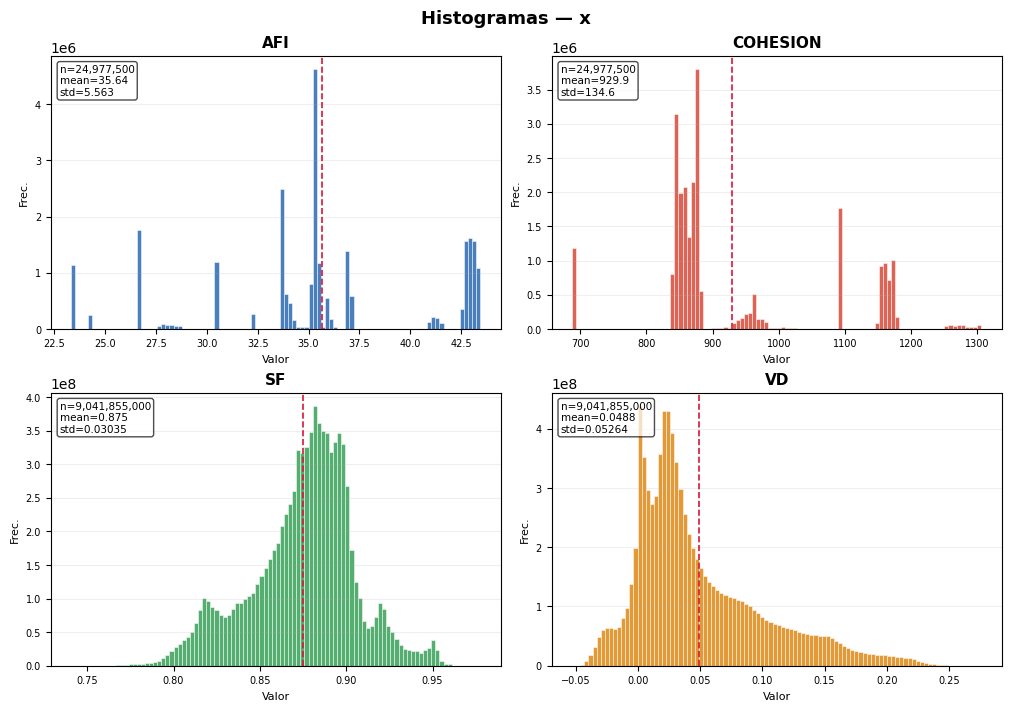

In [5]:
# ── Vista compacta: todos en grilla 2×N ─────────────────────────────────────
COLS    = 2
LOG_Y_G = False

import math as _math
n_rows = _math.ceil(n_vars / COLS)
fig2, axes2 = plt.subplots(n_rows, COLS,
                            figsize=(10, 3.5 * n_rows),
                            constrained_layout=True)
axes2_flat = axes2.ravel() if hasattr(axes2, 'ravel') else [axes2]

for ax, var, color in zip(axes2_flat, variables, PALETTE):
    s      = payload[var]
    edges  = np.asarray(s['bins'],   dtype=np.float64)
    counts = np.asarray(s['counts'], dtype=np.int64)
    ax.bar(edges[:-1], counts, width=np.diff(edges), align='edge',
           color=color, edgecolor='white', linewidth=0.4, alpha=0.88)
    ax.axvline(s['mean'], color='crimson', linewidth=1.2, linestyle='--')
    if LOG_Y_G:
        ax.set_yscale('log')
    ax.set_title(var, fontsize=11, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=8)
    ax.set_ylabel('Frec.', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, axis='y', alpha=0.2)
    ax.text(0.02, 0.97,
            f"n={s['n']:,}\nmean={s['mean']:.4g}\nstd={s['std']:.4g}",
            transform=ax.transAxes, va='top', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.7))

for ax in axes2_flat[n_vars:]:
    ax.axis('off')

fig2.suptitle(f'Histogramas — {JSON_PATH.stem}', fontsize=13, fontweight='bold')
plt.show()